In [13]:
from roboflow import Roboflow
from dotenv import load_dotenv
import os
from ultralytics import YOLO
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

load_dotenv("apikeys.env")
api_key = os.getenv("ROBOFLOW_API_KEY")

In [2]:
rf = Roboflow(api_key=api_key)
project = rf.workspace("semilleroml").project("sitesafety-pbakq")
dataset = project.version(1).download("yolo26")

loading Roboflow workspace...


loading Roboflow project...


In [3]:
# Load a model
model = YOLO("yolo26n.pt")  # load a pretrained model (recommended for training)
# Train the model
results = model.train(data="SiteSafety-1/data.yaml", epochs=20)

New https://pypi.org/project/ultralytics/8.4.34 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.23 🚀 Python-3.12.11 torch-2.8.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=SiteSafety-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train4, nbs=64, nms=

In [23]:
image_path = "/teamspace/studios/this_studio/AIClass/InteligenciaArtificialIS/Lecture09/notebooks/yolo/SiteSafety-1/valid/images/-3154-_png_jpg.rf.bd1c20668ca285cc6ce65742ed5c2cf4.jpg"
resultados = model(image_path, conf=0.001, iou=0.7)


image 1/1 /teamspace/studios/this_studio/AIClass/InteligenciaArtificialIS/Lecture09/notebooks/yolo/SiteSafety-1/valid/images/-3154-_png_jpg.rf.bd1c20668ca285cc6ce65742ed5c2cf4.jpg: 640x640 250 helmets, 50 vests, 15.2ms
Speed: 3.5ms preprocess, 15.2ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)


In [24]:
r = resultados[0] # r es un objeto de tipo 'ultralytics.yolo.engine.results.Results' que contiene toda la informacion de la inferencia

print("=== Informacion general ===")
print(f"Imagen original: {r.path}")
print(f"Tamano procesado: {r.orig_shape}")
print(f"Objetos detectados: {len(r.boxes)}")


print("\n=== Detecciones ===")
for i, box in enumerate(r.boxes):
    clase_id  = int(box.cls[0])
    clase_nom = model.names[clase_id]
    confianza = float(box.conf[0])
    x1, y1, x2, y2 = box.xyxy[0].tolist()
    
    print(f"  [{i+1}] {clase_nom:15s} | confianza: {confianza:.2f} | bbox: ({x1:.0f},{y1:.0f}) → ({x2:.0f},{y2:.0f})")

=== Informacion general ===
Imagen original: /teamspace/studios/this_studio/AIClass/InteligenciaArtificialIS/Lecture09/notebooks/yolo/SiteSafety-1/valid/images/-3154-_png_jpg.rf.bd1c20668ca285cc6ce65742ed5c2cf4.jpg
Tamano procesado: (640, 640)
Objetos detectados: 300

=== Detecciones ===
  [1] vest            | confianza: 0.01 | bbox: (238,505) → (457,640)
  [2] vest            | confianza: 0.01 | bbox: (237,508) → (457,640)
  [3] vest            | confianza: 0.01 | bbox: (229,346) → (457,640)
  [4] vest            | confianza: 0.01 | bbox: (237,498) → (458,640)
  [5] helmet          | confianza: 0.01 | bbox: (243,192) → (421,378)
  [6] helmet          | confianza: 0.01 | bbox: (0,522) → (32,640)
  [7] helmet          | confianza: 0.01 | bbox: (28,534) → (174,640)
  [8] helmet          | confianza: 0.01 | bbox: (44,512) → (287,640)
  [9] vest            | confianza: 0.01 | bbox: (229,306) → (457,640)
  [10] helmet          | confianza: 0.01 | bbox: (330,527) → (466,640)
  [11] vest    

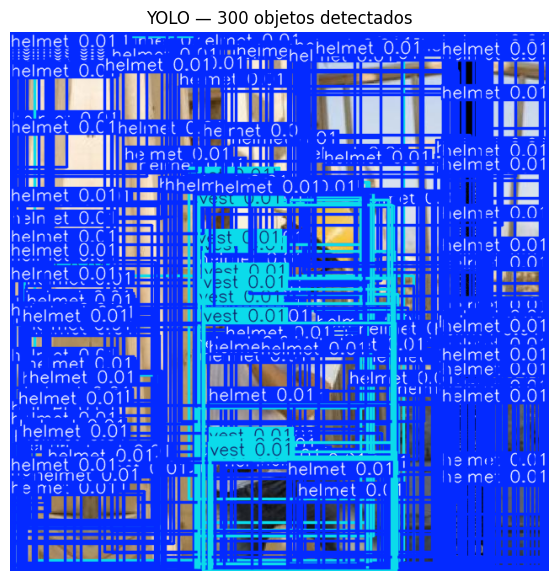

In [20]:
# r.plot() retorna la imagen anotada como array NumPy (BGR → convertir a RGB para matplotlib)
imagen_anotada = r.plot()
imagen_anotada_rgb = imagen_anotada[:, :, ::-1]  # BGR a RGB

plt.figure(figsize=(12, 7))
plt.imshow(imagen_anotada_rgb)
plt.title(f"YOLO — {len(r.boxes)} objetos detectados")
plt.axis("off")
plt.show()